In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.ReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.ReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.ReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.ReLU(),
    nn.MaxPool2d(2),          # 32 → 16
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.ReLU(),
    nn.MaxPool2d(2),          # 16 → 8
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.ReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.ReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.ReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.ReLU(),
    nn.MaxPool2d(2),          # 8 → 4
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.ReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.ReLU(),
    nn.MaxPool2d(2),          # 4 → 2
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model1_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model1_0)
describe(model1_0)

MACs: 7.85 MMac, Params: 56.06 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-4                    [1, 30, 32, 32]           --
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-7                    [1, 30, 32, 32]           --
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-10                   [1, 30, 3

Loading checkpoint from model_weights/model1_0.pt
Starting
Epoch 1/60: Train loss = 1.3244, Train accuracy = 0.5199, Test loss = 1.2906, Test accuracy = 0.5312
Epoch 2/60: Train loss = 1.1281, Train accuracy = 0.6054, Test loss = 1.1111, Test accuracy = 0.6172
Epoch 3/60: Train loss = 0.9384, Train accuracy = 0.6670, Test loss = 0.9094, Test accuracy = 0.6784
Epoch 4/60: Train loss = 0.9745, Train accuracy = 0.6708, Test loss = 0.9827, Test accuracy = 0.6736
Epoch 5/60: Train loss = 0.8205, Train accuracy = 0.7218, Test loss = 0.8441, Test accuracy = 0.7212
Epoch 6/60: Train loss = 0.6946, Train accuracy = 0.7598, Test loss = 0.7241, Test accuracy = 0.7527
Epoch 7/60: Train loss = 0.6691, Train accuracy = 0.7678, Test loss = 0.6840, Test accuracy = 0.7656
Epoch 8/60: Train loss = 0.6576, Train accuracy = 0.7705, Test loss = 0.6867, Test accuracy = 0.7591
Epoch 9/60: Train loss = 0.5963, Train accuracy = 0.7907, Test loss = 0.6288, Test accuracy = 0.7823
Epoch 10/60: Train loss = 0.6227

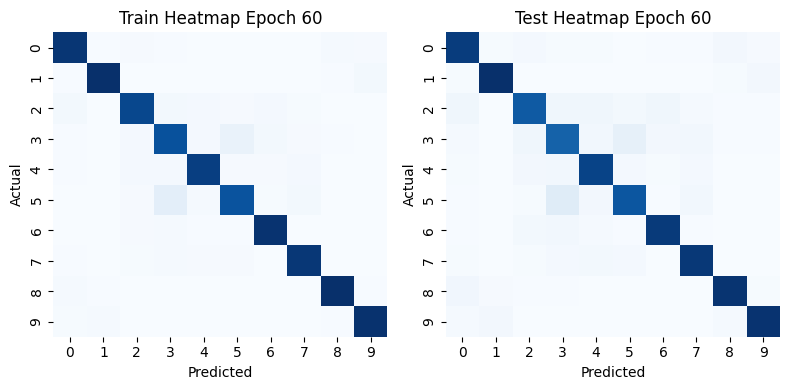

<Figure size 1200x600 with 0 Axes>

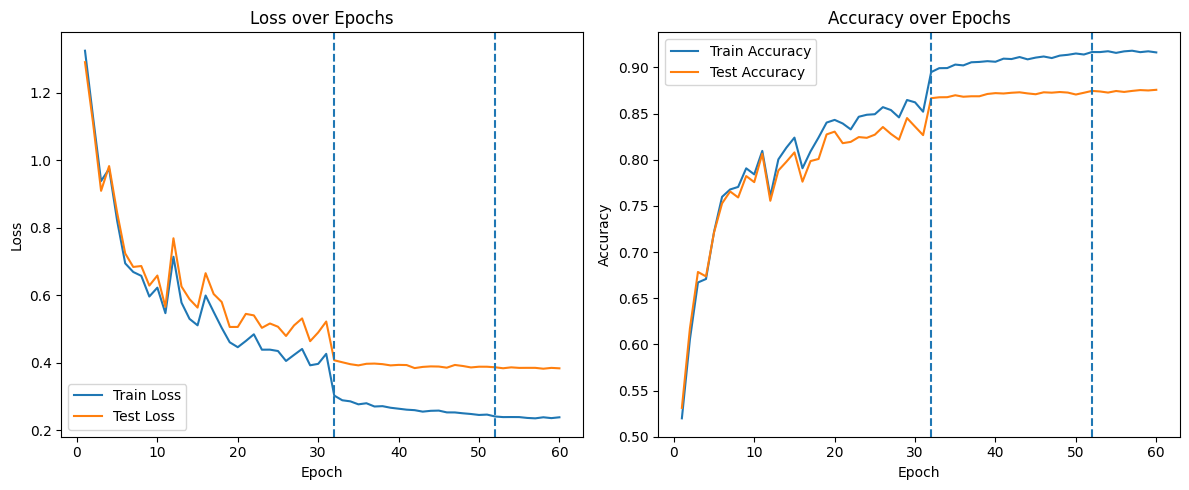

In [6]:
trainf32(model1_0,"model_weights/model1_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model1_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model1_1)
describe(model1_1)

MACs: 7.85 MMac, Params: 56.06 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-4                    [1, 30, 32, 32]           --
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-7                    [1, 30, 32, 32]           --
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─ReLU: 3-10                   [1, 30, 3

Loading checkpoint from model_weights/model1_1.pt
Starting
Epoch 1/60: Train loss = 1.2492, Train accuracy = 0.5760, Test loss = 1.2028, Test accuracy = 0.5986
Epoch 2/60: Train loss = 1.0734, Train accuracy = 0.6240, Test loss = 1.1029, Test accuracy = 0.6231
Epoch 3/60: Train loss = 0.8373, Train accuracy = 0.7057, Test loss = 0.8463, Test accuracy = 0.7028
Epoch 4/60: Train loss = 0.7339, Train accuracy = 0.7472, Test loss = 0.7429, Test accuracy = 0.7466
Epoch 5/60: Train loss = 0.7612, Train accuracy = 0.7350, Test loss = 0.7746, Test accuracy = 0.7342
Epoch 6/60: Train loss = 0.6941, Train accuracy = 0.7629, Test loss = 0.7157, Test accuracy = 0.7619
Epoch 7/60: Train loss = 0.7025, Train accuracy = 0.7577, Test loss = 0.7705, Test accuracy = 0.7398
Epoch 8/60: Train loss = 0.6223, Train accuracy = 0.7808, Test loss = 0.6423, Test accuracy = 0.7784
Epoch 9/60: Train loss = 0.6489, Train accuracy = 0.7733, Test loss = 0.6939, Test accuracy = 0.7659
Epoch 10/60: Train loss = 0.6550

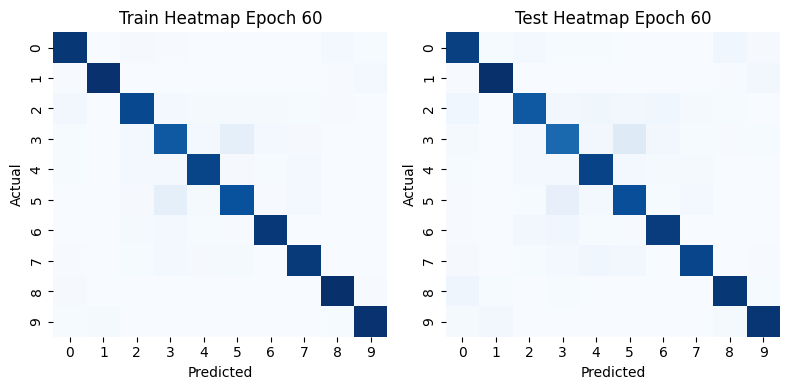

<Figure size 1200x600 with 0 Axes>

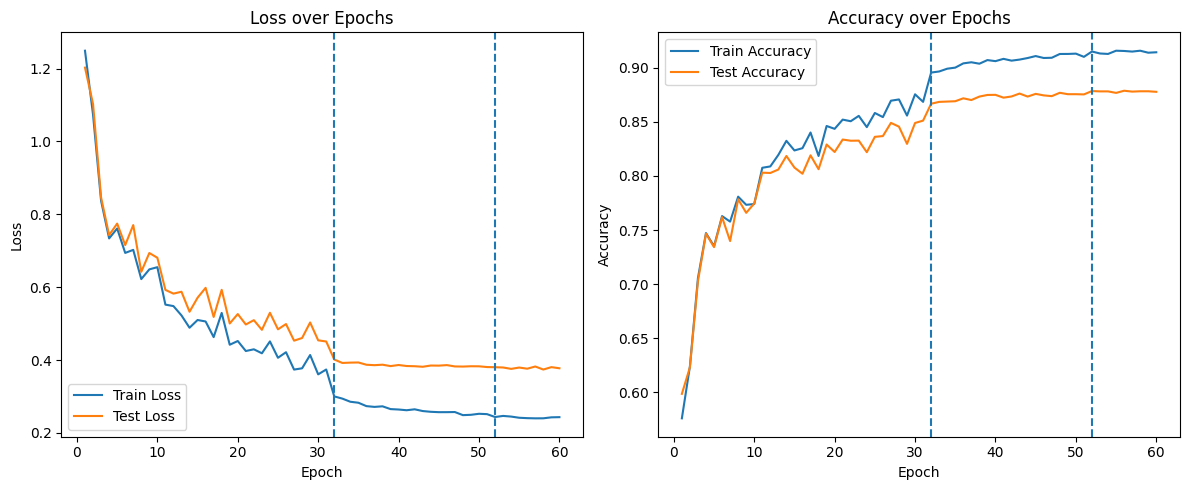

In [8]:
trainf32(model1_1,"model_weights/model1_1.pt",criterion,train_dataset,val_dataset, batch_size=64)